In [1]:
# Import Libraries
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('/content/churn.csv')

# Show first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Check again
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_652/89892915.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [9]:
df.drop('customerID', axis=1, inplace=True)

In [10]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# **CHURN DISTRIBUTION**

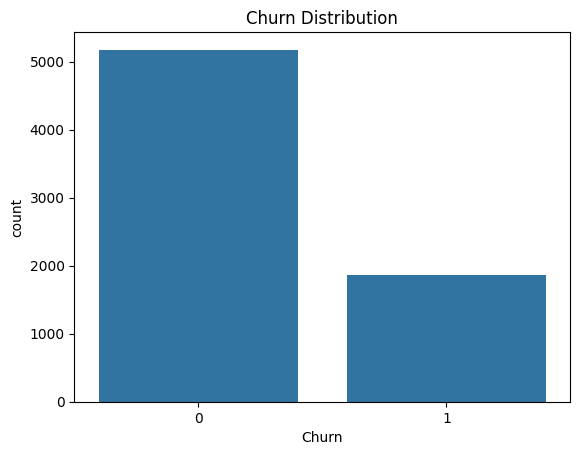

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# **CHURN BY CONTRACT TYPE**

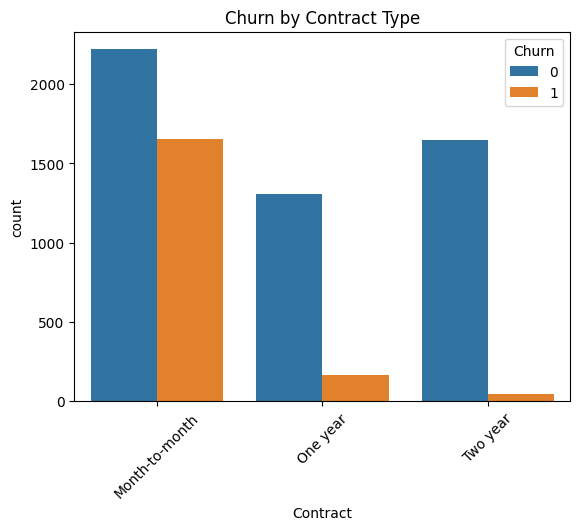

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Contract Type")
plt.show()

# **CHURN VS TENURE**

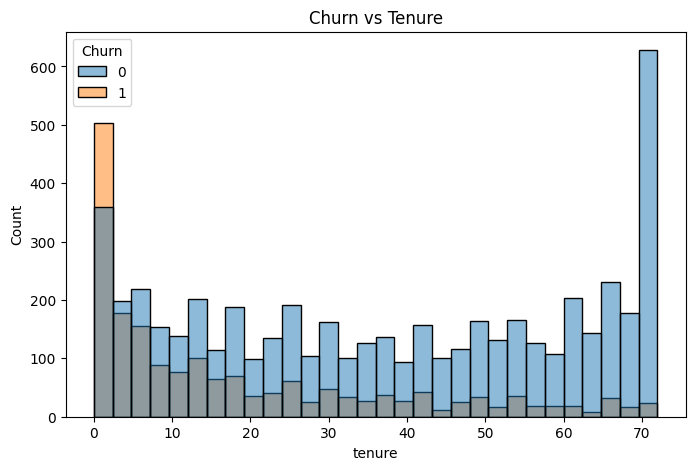

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Churn vs Tenure")
plt.show()

# **CHURN VS MONTHLY CHARGES**

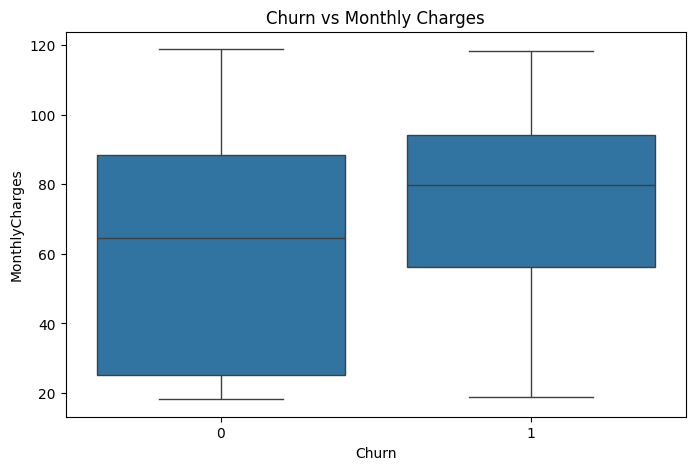

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

# **CHURN BY INTERNET SERVICE**

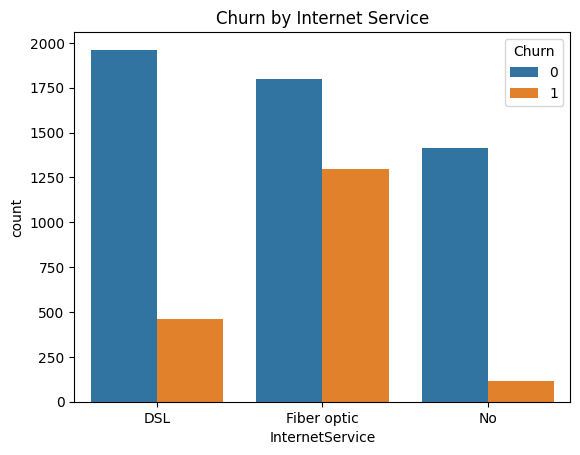

In [16]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

In [17]:
def tenure_group(x):
    if x <= 6:
        return "0-6 Months"
    elif x <= 12:
        return "6-12 Months"
    elif x <= 24:
        return "12-24 Months"
    else:
        return "24+ Months"

df['tenure_group'] = df['tenure'].apply(tenure_group)

In [18]:
df['charge_category'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

In [19]:
services = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in services:
    df[col] = df[col].apply(lambda x: 0 if x in ['No', 'No internet service'] else 1)

df['engagement_score'] = df[services].sum(axis=1)

In [20]:
def contract_risk(x):
    if x == 'Month-to-month':
        return 'High Risk'
    elif x == 'One year':
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['contract_risk'] = df['Contract'].apply(contract_risk)

In [21]:
df[['tenure_group', 'charge_category', 'engagement_score', 'contract_risk']].head()

,tenure_group,charge_category,engagement_score,contract_risk
0,0-6 Months,Low,1,High Risk
1,24+ Months,Medium,3,Medium Risk
2,0-6 Months,Medium,3,High Risk
3,24+ Months,Medium,3,Medium Risk
4,0-6 Months,High,1,High Risk


In [22]:
import sqlite3

conn = sqlite3.connect('churn.db')

df.to_sql('customers', conn, if_exists='replace', index=False)

7043

# **CHURN RATE BY CONTRACT**

In [23]:
query = """
SELECT Contract,
       COUNT(*) AS total_customers,
       SUM(Churn) AS churned_customers,
       ROUND(100.0 * SUM(Churn)/COUNT(*),2) AS churn_rate
FROM customers
GROUP BY Contract
"""

pd.read_sql(query, conn)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


# **REVENUE LOSS FROM CHURN**

In [24]:
query = """
SELECT ROUND(SUM(MonthlyCharges),2) AS lost_revenue
FROM customers
WHERE Churn = 1
"""

pd.read_sql(query, conn)

,lost_revenue
0,139130.85


# **CHURN BY TENURE GROUP**

In [25]:
query = """
SELECT tenure_group,
       COUNT(*) AS total_customers,
       SUM(Churn) AS churned
FROM customers
GROUP BY tenure_group
"""

pd.read_sql(query, conn)

,tenure_group,total_customers,churned
0,0-6 Months,1481,784
1,12-24 Months,1024,294
2,24+ Months,3833,538
3,6-12 Months,705,253


# **HIGH RISK SEGMENT IDENTIFICATION**

In [26]:
query = """
SELECT contract_risk,
       charge_category,
       COUNT(*) AS customers,
       SUM(Churn) AS churned
FROM customers
GROUP BY contract_risk, charge_category
ORDER BY churned DESC
"""

pd.read_sql(query, conn)

,contract_risk,charge_category,customers,churned
0,High Risk,High,2097,1105
1,High Risk,Medium,1070,378
2,High Risk,Low,708,172
3,Medium Risk,High,717,125
4,Low Risk,High,769,37
5,Medium Risk,Medium,371,29
6,Medium Risk,Low,385,12
7,Low Risk,Medium,284,6
8,Low Risk,Low,642,5


In [27]:
# Convert categorical columns into numbers
df_ml = pd.get_dummies(df, drop_first=True)

In [28]:
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [33]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.168845
MonthlyCharges,0.152456
tenure,0.141768
engagement_score,0.039264
InternetService_Fiber optic,0.039115
PaymentMethod_Electronic check,0.037893
tenure_group_24+ Months,0.029168
gender_Male,0.027319
PaperlessBilling_Yes,0.026194
Partner_Yes,0.023552


In [34]:
# Save cleaned dataset to CSV
df.to_csv('cleaned_churn.csv', index=False)

In [35]:
from google.colab import files
files.download('cleaned_churn.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>